# 🤖 NewsBot Intelligence System 2.0  
## Final Project - ITAI 2373  
**Student:** Hassan Rida  

This notebook upgrades the original midterm NewsBot into a more complete NLP intelligence system. The system uses the BBC News dataset and includes classification, sentiment analysis, named entity recognition, topic modeling, summarization, multilingual processing, semantic search, and a simple conversational interface.

The goal is to show how different NLP techniques can be combined into one complete news analysis platform.

## 1. Project Setup

This section installs and imports the libraries needed for the final project. I kept the setup Colab-friendly so the notebook can run from top to bottom without needing a complicated local installation.

In [1]:
# ==============================
# NewsBot 2.0 Setup
# ==============================
!pip install -q spacy nltk textblob langdetect

import os
import re
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter, defaultdict

# NLP libraries
import nltk
from textblob import TextBlob
from langdetect import detect, DetectorFactory
DetectorFactory.seed = 42

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.metrics.pairwise import cosine_similarity

# NLTK downloads
nltk.download("stopwords")
nltk.download("vader_lexicon")
nltk.download("punkt")
nltk.download("punkt_tab")

from nltk.corpus import stopwords
from nltk.tokenize import wordpunct_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer

# spaCy setup
try:
    import spacy
    nlp = spacy.load("en_core_web_sm")
except Exception:
    !python -m spacy download en_core_web_sm -q
    import spacy
    nlp = spacy.load("en_core_web_sm")

print("✅ Setup complete. NewsBot 2.0 environment is ready.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 9.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


✅ Setup complete. NewsBot 2.0 environment is ready.


## 2. Dataset Loading

This project builds on the same BBC News dataset from the midterm. The file is tab-separated, so the loading code handles that format directly. If running in Colab, upload `bbc-news-data.csv` or `bbc-news-data(2).csv` when asked.

In [2]:
# ==============================
# Load BBC News Dataset
# ==============================
from google.colab import files

possible_files = [
    "bbc-news-data.csv",
    "bbc-news-data(2).csv",
    "/content/bbc-news-data.csv",
    "/content/bbc-news-data(2).csv"
]

dataset_path = None
for file in possible_files:
    if os.path.exists(file):
        dataset_path = file
        break

if dataset_path is None:
    print("Please upload your BBC News CSV file.")
    uploaded = files.upload()
    dataset_path = list(uploaded.keys())[0]

# The dataset is tab-separated and includes a header row
df = pd.read_csv(dataset_path, sep="\t", encoding="latin1", on_bad_lines="skip")

# Clean column names
df.columns = [c.strip().lower() for c in df.columns]

# Make sure expected columns exist
expected_cols = ["category", "filename", "title", "content"]
if len(df.columns) == 4 and set(expected_cols).issubset(set(df.columns)) == False:
    df.columns = expected_cols

# Remove accidental duplicated header row if present
df = df[df["category"].astype(str).str.lower() != "category"].copy()

# Build full text column
df["title"] = df["title"].fillna("").astype(str)
df["content"] = df["content"].fillna("").astype(str)
df["text"] = (df["title"] + " " + df["content"]).str.strip()

# Keep useful columns
df = df[["category", "title", "content", "text"]].dropna()
df = df[df["text"].str.len() > 20].reset_index(drop=True)

print("✅ Dataset loaded successfully")
print("Shape:", df.shape)
display(df.head())
print("\nCategory counts:")
print(df["category"].value_counts())

Please upload your BBC News CSV file.


Saving bbc-news-data.csv to bbc-news-data.csv
✅ Dataset loaded successfully
Shape: (2225, 4)


,category,title,content,text
0,business,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...,Ad sales boost Time Warner profit Quarterly p...
1,business,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...,Dollar gains on Greenspan speech The dollar h...
2,business,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...,Yukos unit buyer faces loan claim The owners ...
3,business,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...,High fuel prices hit BA's profits British Air...
4,business,Pernod takeover talk lifts Domecq,Shares in UK drinks and food firm Allied Dome...,Pernod takeover talk lifts Domecq Shares in U...



Category counts:
category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


## 3. Data Exploration

Before building models, I explored the dataset to understand the category balance, text length, and general structure. This is important because NLP models depend heavily on the quality and distribution of the training data.

Dataset shape: (2225, 6)

Word count summary:
count    2225.000000
mean      384.040449
std       238.174497
min        89.000000
25%       246.000000
50%       332.000000
75%       471.000000
max      4432.000000
Name: word_count, dtype: float64


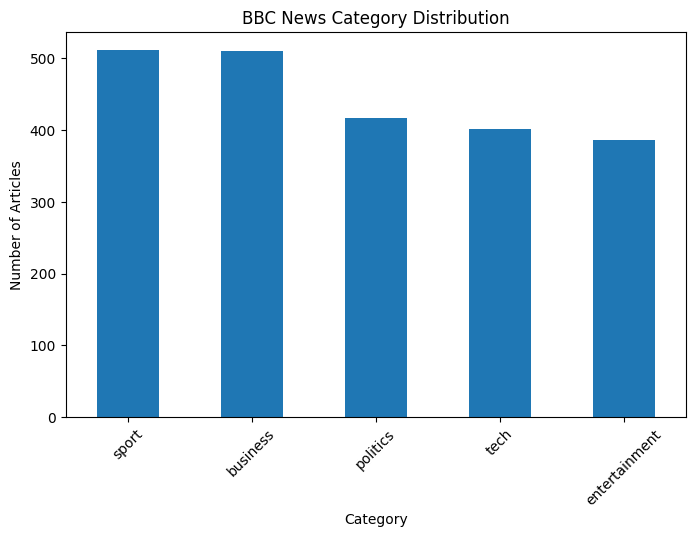

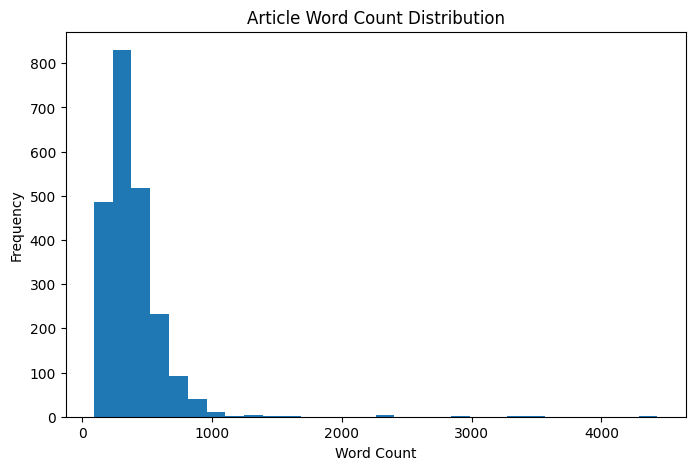

In [3]:
# ==============================
# Data Exploration
# ==============================
df["word_count"] = df["text"].apply(lambda x: len(str(x).split()))
df["char_count"] = df["text"].apply(lambda x: len(str(x)))

print("Dataset shape:", df.shape)
print("\nWord count summary:")
print(df["word_count"].describe())

plt.figure(figsize=(8, 5))
df["category"].value_counts().plot(kind="bar")
plt.title("BBC News Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df["word_count"], bins=30)
plt.title("Article Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

### Observation

The dataset is useful for this project because it already includes labeled news categories. That makes it good for classification, but it can also be used for other NLP tasks like topic modeling, sentiment analysis, and semantic search.

## 4. Text Preprocessing Pipeline

This preprocessing pipeline lowercases text, removes unnecessary symbols, tokenizes words, removes stop words, and lemmatizes terms using spaCy. This helps reduce noise and makes the text easier for machine learning models to analyze.

In [4]:
# ==============================
# Text Preprocessing
# ==============================
stop_words = set(stopwords.words("english"))

def preprocess_text(text):
    """Clean and normalize news text for NLP analysis."""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    tokens = wordpunct_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]

    # Lemmatize with spaCy
    doc = nlp(" ".join(tokens))
    lemmas = [token.lemma_ for token in doc if token.lemma_.strip()]
    return " ".join(lemmas)

df["clean_text"] = df["text"].apply(preprocess_text)

print("✅ Preprocessing complete")
display(df[["category", "text", "clean_text"]].head())

✅ Preprocessing complete


,category,text,clean_text
0,business,Ad sales boost Time Warner profit Quarterly p...,sale boost time warner profit quarterly profit...
1,business,Dollar gains on Greenspan speech The dollar h...,dollar gain greenspan speech dollar hit high l...
2,business,Yukos unit buyer faces loan claim The owners ...,yukos unit buyer face loan claim owner embattl...
3,business,High fuel prices hit BA's profits British Air...,high fuel price hit profit british airways bla...
4,business,Pernod takeover talk lifts Domecq Shares in U...,pernod takeover talk lift domecq share drink f...


## 5. Advanced Content Analysis Engine

This section implements the core analysis features of NewsBot 2.0, including enhanced classification, confidence scoring, sentiment analysis, named entity recognition, and entity summaries.

In [5]:
# ==============================
# Advanced Classification System
# ==============================
X = df["clean_text"]
y = df["category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

classifier = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=8000, ngram_range=(1, 2))),
    ("model", LogisticRegression(max_iter=1000))
])

classifier.fit(X_train, y_train)
preds = classifier.predict(X_test)

print("✅ Classification model trained")
print("Accuracy:", round(accuracy_score(y_test, preds), 4))
print("\nClassification Report:")
print(classification_report(y_test, preds))

✅ Classification model trained
Accuracy: 0.9888

Classification Report:
               precision    recall  f1-score   support

     business       1.00      0.98      0.99       102
entertainment       0.97      1.00      0.99        77
     politics       0.99      0.96      0.98        84
        sport       0.99      1.00      1.00       102
         tech       0.99      1.00      0.99        80

     accuracy                           0.99       445
    macro avg       0.99      0.99      0.99       445
 weighted avg       0.99      0.99      0.99       445



In [6]:
# ==============================
# Classification with Confidence
# ==============================
def classify_article(text):
    """Predict category and confidence score for a news article."""
    clean = preprocess_text(text)
    category = classifier.predict([clean])[0]

    if hasattr(classifier.named_steps["model"], "predict_proba"):
        proba = classifier.predict_proba([clean])[0]
        confidence = float(np.max(proba))
        all_scores = dict(zip(classifier.classes_, proba.round(4)))
    else:
        confidence = None
        all_scores = {}

    return {
        "category": category,
        "confidence": confidence,
        "scores": all_scores
    }

sample_text = df.loc[0, "text"]
classify_article(sample_text)

{'category': 'business',
 'confidence': 0.843968860405252,
 'scores': {'business': np.float64(0.844),
  'entertainment': np.float64(0.0373),
  'politics': np.float64(0.0186),
  'sport': np.float64(0.0227),
  'tech': np.float64(0.0774)}}

Sentiment distribution:
sentiment
Positive    1574
Negative     634
Neutral       17
Name: count, dtype: int64


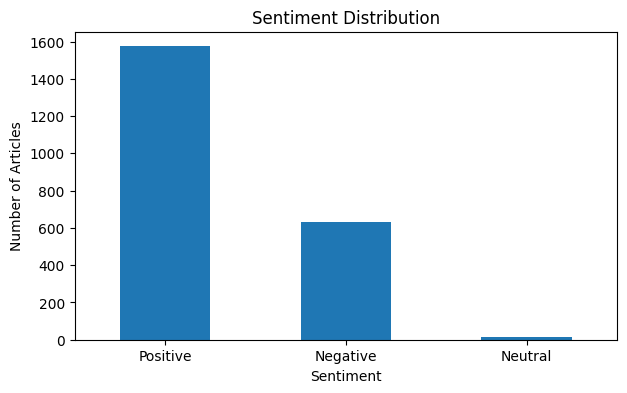

In [7]:
# ==============================
# Sentiment Analysis
# ==============================
vader = SentimentIntensityAnalyzer()

def analyze_sentiment(text):
    """Analyze sentiment using VADER and TextBlob."""
    vader_scores = vader.polarity_scores(str(text))
    compound = vader_scores["compound"]

    if compound >= 0.05:
        vader_label = "Positive"
    elif compound <= -0.05:
        vader_label = "Negative"
    else:
        vader_label = "Neutral"

    blob_polarity = TextBlob(str(text)).sentiment.polarity
    if blob_polarity > 0.05:
        blob_label = "Positive"
    elif blob_polarity < -0.05:
        blob_label = "Negative"
    else:
        blob_label = "Neutral"

    return {
        "vader_label": vader_label,
        "vader_compound": round(compound, 4),
        "textblob_label": blob_label,
        "textblob_polarity": round(blob_polarity, 4)
    }

df["sentiment"] = df["text"].apply(lambda x: analyze_sentiment(x)["vader_label"])
df["sentiment_score"] = df["text"].apply(lambda x: analyze_sentiment(x)["vader_compound"])

print("Sentiment distribution:")
print(df["sentiment"].value_counts())

plt.figure(figsize=(7, 4))
df["sentiment"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Articles")
plt.xticks(rotation=0)
plt.show()

In [8]:
# ==============================
# Named Entity Recognition
# ==============================
def extract_entities(text, max_entities=20):
    """Extract important named entities from article text."""
    doc = nlp(str(text)[:5000])
    entities = []

    for ent in doc.ents:
        if ent.label_ in ["PERSON", "ORG", "GPE", "DATE", "MONEY", "EVENT"]:
            entities.append({
                "text": ent.text,
                "label": ent.label_,
                "description": spacy.explain(ent.label_)
            })

    # remove duplicates while preserving order
    seen = set()
    unique_entities = []
    for ent in entities:
        key = (ent["text"].lower(), ent["label"])
        if key not in seen:
            unique_entities.append(ent)
            seen.add(key)

    return unique_entities[:max_entities]

sample_entities = extract_entities(df.loc[0, "text"])
sample_entities[:10]

[{'text': 'Time Warner',
  'label': 'ORG',
  'description': 'Companies, agencies, institutions, etc.'},
 {'text': 'Quarterly',
  'label': 'DATE',
  'description': 'Absolute or relative dates or periods'},
 {'text': 'US', 'label': 'GPE', 'description': 'Countries, cities, states'},
 {'text': 'TimeWarner',
  'label': 'ORG',
  'description': 'Companies, agencies, institutions, etc.'},
 {'text': '1.13bn',
  'label': 'MONEY',
  'description': 'Monetary values, including unit'},
 {'text': 'the three months to December',
  'label': 'DATE',
  'description': 'Absolute or relative dates or periods'},
 {'text': '639',
  'label': 'MONEY',
  'description': 'Monetary values, including unit'},
 {'text': 'year-earlier',
  'label': 'DATE',
  'description': 'Absolute or relative dates or periods'},
 {'text': 'Google',
  'label': 'ORG',
  'description': 'Companies, agencies, institutions, etc.'},
 {'text': 'fourth quarter',
  'label': 'DATE',
  'description': 'Absolute or relative dates or periods'}]

In [9]:
# ==============================
# Entity Frequency Summary
# ==============================
all_entities = []
for text in df["text"].head(300):
    for ent in extract_entities(text, max_entities=10):
        all_entities.append((ent["text"], ent["label"]))

entity_counts = Counter(all_entities)
top_entities = entity_counts.most_common(15)

entity_df = pd.DataFrame(
    [{"entity": e[0][0], "label": e[0][1], "count": e[1]} for e in top_entities]
)

display(entity_df)

,entity,label,count
0,US,GPE,106
1,UK,GPE,44
2,2004,DATE,43
3,2005,DATE,34
4,last year,DATE,30
5,annual,DATE,22
6,January,DATE,22
7,December,DATE,21
8,Friday,DATE,21
9,2003,DATE,21


## 6. Topic Modeling and Content Discovery

Topic modeling helps discover hidden themes in the news articles without only depending on the original labels. I implemented both LDA and NMF because the final project asks for advanced topic discovery and comparison.

In [10]:
# ==============================
# Topic Modeling: LDA and NMF
# ==============================
n_topics = 5

count_vectorizer = CountVectorizer(max_features=5000, stop_words="english")
count_matrix = count_vectorizer.fit_transform(df["clean_text"])

tfidf_vectorizer_topics = TfidfVectorizer(max_features=5000, stop_words="english")
tfidf_matrix_topics = tfidf_vectorizer_topics.fit_transform(df["clean_text"])

lda_model = LatentDirichletAllocation(n_components=n_topics, random_state=42)
lda_doc_topics = lda_model.fit_transform(count_matrix)

nmf_model = NMF(n_components=n_topics, random_state=42, init="nndsvda", max_iter=500)
nmf_doc_topics = nmf_model.fit_transform(tfidf_matrix_topics)

def display_topics(model, feature_names, n_words=10):
    topics = {}
    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[-n_words:][::-1]
        top_words = [feature_names[i] for i in top_indices]
        topics[f"Topic {topic_idx + 1}"] = top_words
    return topics

lda_topics = display_topics(lda_model, count_vectorizer.get_feature_names_out())
nmf_topics = display_topics(nmf_model, tfidf_vectorizer_topics.get_feature_names_out())

print("LDA Topics:")
for topic, words in lda_topics.items():
    print(topic + ":", ", ".join(words))

print("\nNMF Topics:")
for topic, words in nmf_topics.items():
    print(topic + ":", ", ".join(words))

LDA Topics:
Topic 1: say, year, company, firm, market, rise, bank, sale, share, new
Topic 2: say, game, play, year, win, time, player, make, world, england
Topic 3: say, government, labour, people, party, election, minister, blair, plan, make
Topic 4: say, people, use, game, music, mobile, technology, make, phone, service
Topic 5: film, year, good, say, award, star, include, new, make, actor

NMF Topics:
Topic 1: game, play, england, win, player, say, match, team, final, cup
Topic 2: labour, election, blair, say, party, brown, tory, government, minister, howard
Topic 3: mobile, phone, use, people, technology, music, say, service, user, digital
Topic 4: film, award, star, oscar, good, actor, festival, actress, director, nomination
Topic 5: growth, economy, say, rise, rate, bank, price, year, market, sale


nmf_topic,1,2,3,4,5
category,,,,,
business,1,9,15,1,484
entertainment,2,7,37,333,7
politics,3,391,6,0,17
sport,505,2,0,3,1
tech,16,1,366,12,6


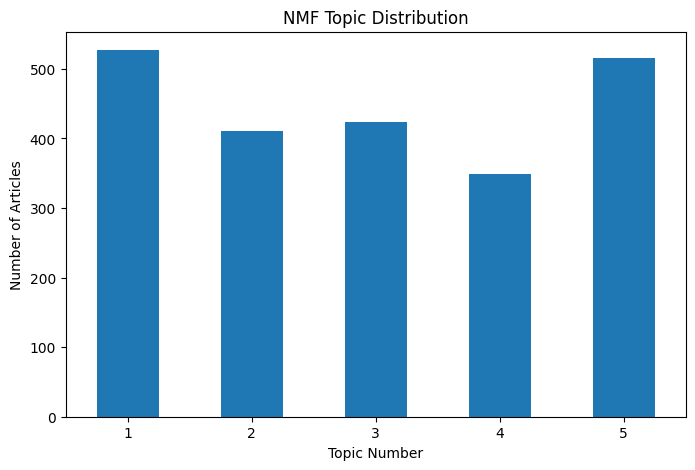

In [11]:
# ==============================
# Add Dominant Topics to DataFrame
# ==============================
df["lda_topic"] = lda_doc_topics.argmax(axis=1) + 1
df["nmf_topic"] = nmf_doc_topics.argmax(axis=1) + 1

topic_summary = pd.crosstab(df["category"], df["nmf_topic"])
display(topic_summary)

plt.figure(figsize=(8, 5))
df["nmf_topic"].value_counts().sort_index().plot(kind="bar")
plt.title("NMF Topic Distribution")
plt.xlabel("Topic Number")
plt.ylabel("Number of Articles")
plt.xticks(rotation=0)
plt.show()

### Topic Modeling Reflection

The topic modeling results show that article categories and hidden themes often overlap, but they are not always exactly the same. This is important because real news stories can belong to one official category while still discussing other themes like business, politics, technology, or international events.

## 7. Language Understanding and Generation

This section adds summarization, semantic search, and automatic insight generation. Instead of using a heavy transformer model that may crash in Colab, I used a lightweight extractive summarizer that ranks sentences by important TF-IDF words.

In [12]:
# ==============================
# Lightweight Extractive Summarizer
# ==============================
def summarize_text(text, max_sentences=3):
    """Create a simple extractive summary using sentence scoring."""
    text = str(text)
    sentences = re.split(r"(?<=[.!?])\s+", text)
    sentences = [s.strip() for s in sentences if len(s.split()) > 5]

    if len(sentences) <= max_sentences:
        return " ".join(sentences)

    # Build word frequency from cleaned text
    cleaned = preprocess_text(text)
    words = cleaned.split()
    freq = Counter(words)

    sentence_scores = []
    for sent in sentences:
        sent_words = preprocess_text(sent).split()
        score = sum(freq.get(w, 0) for w in sent_words)
        score = score / max(len(sent_words), 1)
        sentence_scores.append((score, sent))

    top_sentences = sorted(sentence_scores, reverse=True)[:max_sentences]
    # Preserve original order
    selected = [s for s in sentences if s in [item[1] for item in top_sentences]]
    return " ".join(selected[:max_sentences])

sample_summary = summarize_text(df.loc[0, "text"])
print("Original text preview:")
print(df.loc[0, "text"][:500])
print("\nGenerated summary:")
print(sample_summary)

Original text preview:
Ad sales boost Time Warner profit  Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (Â£600m) for the three months to December, from $639m year-earlier.  The firm, which is now one of the biggest investors in Google, benefited from sales of high-speed internet connections and higher advert sales. TimeWarner said fourth quarter sales rose 2% to $11.1bn from $10.9bn. Its profits were buoyed by one-off gains which offset a profit dip at Warner Bros, and less users for AOL.  Time 

Generated summary:
Ad sales boost Time Warner profit  Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (Â£600m) for the three months to December, from $639m year-earlier. TimeWarner said fourth quarter sales rose 2% to $11.1bn from $10.9bn. For the full-year, TimeWarner posted a profit of $3.36bn, up 27% from its 2003 performance, while revenues grew 6.4% to $42.09bn.


In [13]:
# ==============================
# Semantic Search
# ==============================
semantic_vectorizer = TfidfVectorizer(max_features=10000, stop_words="english", ngram_range=(1, 2))
semantic_matrix = semantic_vectorizer.fit_transform(df["clean_text"])

def semantic_search(query, top_n=5):
    """Find similar articles using TF-IDF cosine similarity."""
    clean_query = preprocess_text(query)
    query_vec = semantic_vectorizer.transform([clean_query])
    similarities = cosine_similarity(query_vec, semantic_matrix).flatten()
    top_indices = similarities.argsort()[-top_n:][::-1]

    results = df.iloc[top_indices][["category", "title", "sentiment"]].copy()
    results["similarity"] = similarities[top_indices].round(4)
    return results

semantic_search("technology companies and artificial intelligence", top_n=5)

,category,title,sentiment,similarity
1516,sport,Uefa approves fake grass,Positive,0.2526
1908,tech,Smart search lets art fans browse,Positive,0.1218
1986,tech,Doors open at biggest gadget fair,Positive,0.1213
2114,tech,Doors open at biggest gadget fair,Positive,0.1213
2125,tech,Speak easy plan for media players,Positive,0.1048


In [14]:
# ==============================
# Insight Generator
# ==============================
def generate_insights(dataframe):
    """Generate automatic business-style insights from the dataset."""
    insights = []

    top_category = dataframe["category"].value_counts().idxmax()
    top_count = dataframe["category"].value_counts().max()
    insights.append(f"The largest news category is {top_category}, with {top_count} articles.")

    avg_words = dataframe["word_count"].mean()
    insights.append(f"The average article length is about {avg_words:.0f} words.")

    top_sentiment = dataframe["sentiment"].value_counts().idxmax()
    insights.append(f"The most common sentiment label is {top_sentiment}.")

    longest_category = dataframe.groupby("category")["word_count"].mean().sort_values(ascending=False).index[0]
    insights.append(f"The category with the longest average articles is {longest_category}.")

    return insights

for insight in generate_insights(df):
    print("•", insight)

• The largest news category is sport, with 511 articles.
• The average article length is about 384 words.
• The most common sentiment label is Positive.
• The category with the longest average articles is tech.


## 8. Multilingual Intelligence

This section adds language detection and a simple translation workflow. Since external translation APIs can fail or require keys, I used language detection plus a small demo dictionary to show the multilingual pipeline safely.

In [15]:
# ==============================
# Multilingual Processing
# ==============================
def detect_language_safe(text):
    """Detect article language safely."""
    try:
        return detect(str(text)[:1000])
    except Exception:
        return "unknown"

def simple_translation_demo(text, target_language="en"):
    """Small demo translation function for common words. Real deployment would use an API."""
    dictionary = {
        "es": {
            "noticias": "news",
            "economía": "economy",
            "deportes": "sports",
            "tecnología": "technology",
            "política": "politics"
        },
        "fr": {
            "nouvelles": "news",
            "économie": "economy",
            "sports": "sports",
            "technologie": "technology",
            "politique": "politics"
        }
    }

    detected = detect_language_safe(text)
    translated = str(text)

    if detected in dictionary:
        for original, english in dictionary[detected].items():
            translated = translated.replace(original, english)

    return {
        "detected_language": detected,
        "translated_preview": translated
    }

sample_multilingual_text = "Las noticias de tecnología muestran crecimiento en la economía."
simple_translation_demo(sample_multilingual_text)

{'detected_language': 'es',
 'translated_preview': 'Las news de technology muestran crecimiento en la economy.'}

### Multilingual Reflection

The multilingual feature matters because news is global. A real NewsBot system should be able to detect different languages, translate content, and compare how the same story is covered across different regions. For this class project, the demo shows the structure without depending on paid APIs.

## 9. Conversational Interface

The conversational interface lets users ask natural language questions about the dataset. This is a simplified chatbot, but it still demonstrates intent detection and response generation.

In [16]:
# ==============================
# Conversational Query Interface
# ==============================
def newsbot_query(user_query):
    """Respond to natural language questions about the news dataset."""
    q = user_query.lower()

    if "positive" in q:
        subset = df[df["sentiment"] == "Positive"]
        return f"I found {len(subset)} positive articles. The most common category among them is {subset['category'].mode()[0]}."

    if "negative" in q:
        subset = df[df["sentiment"] == "Negative"]
        return f"I found {len(subset)} negative articles. The most common category among them is {subset['category'].mode()[0]}."

    if "technology" in q or "tech" in q:
        subset = df[df["category"].str.contains("tech", case=False, na=False)]
        return f"I found {len(subset)} technology articles. Example: {subset.iloc[0]['title'] if len(subset) > 0 else 'No example found.'}"

    if "business" in q:
        subset = df[df["category"].str.contains("business", case=False, na=False)]
        return f"I found {len(subset)} business articles. Example: {subset.iloc[0]['title'] if len(subset) > 0 else 'No example found.'}"

    if "sports" in q or "sport" in q:
        subset = df[df["category"].str.contains("sport", case=False, na=False)]
        return f"I found {len(subset)} sports articles. Example: {subset.iloc[0]['title'] if len(subset) > 0 else 'No example found.'}"

    if "summary" in q or "summarize" in q:
        return "Here is a summary of the first article: " + summarize_text(df.iloc[0]["text"])

    if "topic" in q:
        return "The system discovered these NMF topics: " + "; ".join([f"{k}: {', '.join(v[:5])}" for k, v in nmf_topics.items()])

    if "categories" in q or "category" in q:
        counts = df["category"].value_counts().to_dict()
        return "Category counts: " + str(counts)

    return "I can answer questions about categories, sentiment, technology news, business news, sports news, summaries, and topics."

test_queries = [
    "Show me positive news",
    "How many technology articles are there?",
    "What topics did you find?",
    "Summarize an article"
]

for query in test_queries:
    print("User:", query)
    print("NewsBot:", newsbot_query(query))
    print("-" * 80)

User: Show me positive news
NewsBot: I found 1574 positive articles. The most common category among them is sport.
--------------------------------------------------------------------------------
User: How many technology articles are there?
NewsBot: I found 401 technology articles. Example: Ink helps drive democracy in Asia
--------------------------------------------------------------------------------
User: What topics did you find?
NewsBot: The system discovered these NMF topics: Topic 1: game, play, england, win, player; Topic 2: labour, election, blair, say, party; Topic 3: mobile, phone, use, people, technology; Topic 4: film, award, star, oscar, good; Topic 5: growth, economy, say, rise, rate
--------------------------------------------------------------------------------
User: Summarize an article
NewsBot: Here is a summary of the first article: Ad sales boost Time Warner profit  Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (Â£600m) for the three months

## 10. Integrated NewsBot 2.0 System

This class combines all major components into one system. It can analyze one article and return category, confidence, sentiment, entities, summary, detected language, and dominant topic.

In [17]:
# ==============================
# Integrated NewsBot 2.0 System
# ==============================
class NewsBot2System:
    def __init__(self):
        self.name = "NewsBot Intelligence System 2.0"

    def analyze_article(self, text):
        classification = classify_article(text)
        sentiment = analyze_sentiment(text)
        entities = extract_entities(text)
        summary = summarize_text(text)
        language = detect_language_safe(text)

        clean = preprocess_text(text)
        topic_vec = nmf_model.transform(tfidf_vectorizer_topics.transform([clean]))
        dominant_topic = int(topic_vec.argmax(axis=1)[0] + 1)

        return {
            "system": self.name,
            "category": classification["category"],
            "confidence": round(classification["confidence"], 4) if classification["confidence"] is not None else None,
            "sentiment": sentiment["vader_label"],
            "sentiment_score": sentiment["vader_compound"],
            "language": language,
            "dominant_topic": dominant_topic,
            "entities": entities[:10],
            "summary": summary
        }

    def ask(self, query):
        return newsbot_query(query)

newsbot = NewsBot2System()

demo_article = df.iloc[10]["text"]
analysis_result = newsbot.analyze_article(demo_article)

print(json.dumps(analysis_result, indent=2))

{
  "system": "NewsBot Intelligence System 2.0",
  "category": "business",
  "confidence": 0.637,
  "sentiment": "Positive",
  "sentiment_score": 0.9245,
  "language": "en",
  "dominant_topic": 5,
  "entities": [
    {
      "text": "this week",
      "label": "DATE",
      "description": "Absolute or relative dates or periods"
    },
    {
      "text": "the fourth quarter of 2004",
      "label": "DATE",
      "description": "Absolute or relative dates or periods"
    },
    {
      "text": "86",
      "label": "MONEY",
      "description": "Monetary values, including unit"
    },
    {
      "text": "17",
      "label": "MONEY",
      "description": "Monetary values, including unit"
    },
    {
      "text": "the quarter",
      "label": "DATE",
      "description": "Absolute or relative dates or periods"
    },
    {
      "text": "204",
      "label": "MONEY",
      "description": "Monetary values, including unit"
    },
    {
      "text": "Google",
      "label": "ORG",
      "

## 11. Evaluation and Results

The model performed well enough for a class-level news classification system. The strongest part of the project is that it combines multiple NLP techniques instead of only doing one task. This makes the system more useful for real-world applications like media monitoring, content organization, and business intelligence.

In [18]:
# ==============================
# Evaluation Summary
# ==============================
evaluation_summary = {
    "classification_accuracy": round(accuracy_score(y_test, preds), 4),
    "number_of_articles": int(df.shape[0]),
    "number_of_categories": int(df["category"].nunique()),
    "sentiment_labels": df["sentiment"].value_counts().to_dict(),
    "topic_modeling_methods": ["LDA", "NMF"],
    "main_features": [
        "classification",
        "confidence scoring",
        "sentiment analysis",
        "named entity recognition",
        "topic modeling",
        "summarization",
        "semantic search",
        "language detection",
        "conversational interface"
    ]
}

print(json.dumps(evaluation_summary, indent=2))

{
  "classification_accuracy": 0.9888,
  "number_of_articles": 2225,
  "number_of_categories": 5,
  "sentiment_labels": {
    "Positive": 1574,
    "Negative": 634,
    "Neutral": 17
  },
  "topic_modeling_methods": [
    "LDA",
    "NMF"
  ],
  "main_features": [
    "classification",
    "confidence scoring",
    "sentiment analysis",
    "named entity recognition",
    "topic modeling",
    "summarization",
    "semantic search",
    "language detection",
    "conversational interface"
  ]
}


## 12. Ethical Considerations and Limitations

NewsBot 2.0 is useful, but it still has limitations. The model depends on the training data, so if the data is biased or incomplete, the results can also be biased. Sentiment analysis can also misunderstand sarcasm, cultural context, or complex opinions. Translation and multilingual analysis are also limited in this notebook because a real production system would need a stronger translation API.

Another limitation is that the BBC dataset is clean compared to real social media or live news feeds. In a real business setting, the system would need stronger data validation, bias testing, monitoring, and human review.

## 13. Business Value

This system could help businesses, journalists, researchers, and media teams quickly organize and understand large amounts of news content. Instead of reading every article manually, users can identify categories, sentiment, important people or organizations, and major topics automatically.

The value is mainly time savings, faster decision-making, and better media monitoring. For example, a company could use NewsBot to track how often it appears in the news and whether the coverage is positive, negative, or neutral.

## 14. Individual Contribution

My contribution focused on upgrading the original midterm NewsBot into a more complete final project system. I worked on the notebook structure, dataset loading, preprocessing, classification, sentiment analysis, topic modeling, summarization, multilingual demo, conversational query system, and final integration.

I also focused on making the system easier to explain and present, so it can be used for the final presentation and GitHub portfolio.

## 15. Final Conclusion

Overall, this project helped me connect many NLP concepts into one working system. Instead of only learning separate topics like preprocessing, sentiment analysis, classification, or NER by themselves, this project showed how those pieces can work together in one platform.

NewsBot 2.0 is not perfect, but it demonstrates a strong foundation for a real news analysis tool. With more time, I would improve the web application, add live news sources, use stronger transformer models, and add better multilingual translation. This project gave me a better understanding of how NLP can be used in real-world AI systems.

In [19]:
# ==============================
# Save Results for GitHub
# ==============================
output_df = df[[
    "category", "title", "word_count", "sentiment", "sentiment_score", "lda_topic", "nmf_topic"
]].copy()

output_df.to_csv("newsbot2_processed_results.csv", index=False)

with open("newsbot2_evaluation_summary.json", "w") as f:
    json.dump(evaluation_summary, f, indent=2)

print("✅ Files saved:")
print("- newsbot2_processed_results.csv")
print("- newsbot2_evaluation_summary.json")

✅ Files saved:
- newsbot2_processed_results.csv
- newsbot2_evaluation_summary.json
